In [1]:
"""
Cross-Project Vulnerability Detection on PrimeVul
--------------------------------------------------
Train on ALL projects EXCEPT poppler -> Test on poppler
SVMSMOTE Oversampling
"""

import os
import json
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    roc_auc_score, f1_score, confusion_matrix
)
from imblearn.over_sampling import SVMSMOTE
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# =========================================================
# Config
# =========================================================
SEED        = 42
TEST_PROJ   = "poppler"
COMBINED_FILE = "../../../../embedding/primevul/codebert/primevul_embedded.jsonl"
EMB_KEY     = "emb"
OUTPUT_DIR  = "results/svmsmote/poppler"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = "mps"
    torch.mps.manual_seed(SEED)
elif torch.cuda.is_available():
    DEVICE = "cuda"
    torch.cuda.manual_seed_all(SEED)
else:
    DEVICE = "cpu"


# =========================================================
# Data Loading
# =========================================================
def load_jsonl(path):
    records = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    X        = np.array([r[EMB_KEY]   for r in records], dtype=np.float32)
    y        = np.array([r["target"]  for r in records], dtype=np.int32)
    projects = np.array([r["project"] for r in records], dtype=object)
    return X, y, projects


# =========================================================
# Neural Network
# =========================================================
class VulnerabilityClassifier(nn.Module):
    def __init__(self, input_dim):
        super(VulnerabilityClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


# =========================================================
# Training Loop with Validation
# =========================================================
def train_neural_network(model, dataloader, x_val, y_val,
                          optimizer, criterion, epochs, desc):
    for epoch in tqdm(range(epochs), desc=desc, leave=False):
        model.train()
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(x_batch).squeeze(), y_batch)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(x_val).squeeze(), y_val).item()
        print(f"      {desc} | Epoch {epoch+1}/{epochs} - val_loss: {val_loss:.4f}")

    return model


# =========================================================
# Semi-supervised Transfer Learning
# =========================================================
def semi_supervised_transfer_learning(x_train, y_train, x_test, iteration):
    x_tr, x_val, y_tr, y_val = train_test_split(
        x_train, y_train,
        test_size=0.2,
        random_state=SEED
    )

    x_tr_t   = torch.tensor(x_tr,   dtype=torch.float32)
    y_tr_t   = torch.tensor(y_tr,   dtype=torch.float32)
    x_val_t  = torch.tensor(x_val,  dtype=torch.float32).to(DEVICE)
    y_val_t  = torch.tensor(y_val,  dtype=torch.float32).to(DEVICE)
    x_test_t = torch.tensor(x_test, dtype=torch.float32)

    dataset    = TensorDataset(x_tr_t, y_tr_t)
    dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

    model     = VulnerabilityClassifier(x_train.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
    criterion = nn.BCELoss()

    # Phase 1: Train on SVMSMOTE-oversampled source (all-except-poppler)
    model = train_neural_network(
        model, dataloader, x_val_t, y_val_t,
        optimizer, criterion,
        epochs=50,
        desc=f"Iter {iteration} - Phase 1"
    )

    # Pseudo-label the test set (poppler)
    model.eval()
    with torch.no_grad():
        y_pred        = model(x_test_t.to(DEVICE)).squeeze().cpu().numpy()
        y_pred_binary = (y_pred > 0.5).astype(int)

    # Phase 2: Fine-tune on source + pseudo-labelled poppler
    x_train_aug    = np.concatenate((x_train, x_test))
    y_train_aug    = np.concatenate((y_train, y_pred_binary))
    x_aug_t        = torch.tensor(x_train_aug, dtype=torch.float32)
    y_aug_t        = torch.tensor(y_train_aug, dtype=torch.float32)
    x_aug_val_t    = torch.tensor(x_val, dtype=torch.float32).to(DEVICE)
    y_aug_val_t    = torch.tensor(y_val, dtype=torch.float32).to(DEVICE)
    dataset_aug    = TensorDataset(x_aug_t, y_aug_t)
    dataloader_aug = DataLoader(dataset_aug, batch_size=32, shuffle=True)

    model = train_neural_network(
        model, dataloader_aug, x_aug_val_t, y_aug_val_t,
        optimizer, criterion,
        epochs=30,
        desc=f"Iter {iteration} - Phase 2"
    )

    model.eval()
    with torch.no_grad():
        y_pred_final = model(x_test_t.to(DEVICE)).squeeze().cpu().numpy()

    return model, y_pred_final


# =========================================================
# XGBoost
# =========================================================
def train_base_model_xgb(x_train, y_train, sample_weights=None):
    model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        eval_metric='logloss',
        random_state=SEED
    )
    model.fit(x_train, y_train, sample_weight=sample_weights)
    return model


# =========================================================
# Confusion Matrix Plot
# =========================================================
def plot_confusion_matrix(tn, fp, fn, tp, save_path):
    cm = np.array([[tn, fp],
                   [fn, tp]])

    fig, ax = plt.subplots(figsize=(6, 5))
    img = ax.imshow(cm, interpolation='nearest')
    ax.set_title("Confusion Matrix (poppler Test Set)")
    plt.colorbar(img, ax=ax)

    tick_marks = np.arange(2)
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(["Non-Vulnerable", "Vulnerable"])
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(["Non-Vulnerable", "Vulnerable"])

    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            color = "black" if cm[i, j] > thresh else "white"
            ax.text(j, i, cm[i, j], ha="center", va="center", color=color)

    ax.set_ylabel("Actual Label")
    ax.set_xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    print(f"Confusion matrix saved as {save_path}")
    plt.show()


# =========================================================
# Main
# =========================================================
def main():
    print(f"\n=== PrimeVul | Train on ALL except poppler -> Test on poppler (SVMSMOTE) ===")
    print(f"    Device: {DEVICE}")

    # ----------------------------------------------------------
    # [1/5] Load combined embeddings and split by project
    # ----------------------------------------------------------
    print("\n[1/5] Loading combined embeddings...")

    X_all, y_all, proj_all = load_jsonl(COMBINED_FILE)

    train_mask = proj_all != TEST_PROJ
    train_emb  = X_all[train_mask].astype(np.float32)
    train_lbl  = y_all[train_mask].astype(np.int32)

    test_mask = proj_all == TEST_PROJ
    test_emb  = X_all[test_mask].astype(np.float32)
    test_lbl  = y_all[test_mask].astype(np.int32)

    if train_emb.shape[0] == 0:
        raise ValueError("Training pool is empty. Check COMBINED_FILE path.")
    if test_emb.shape[0] == 0:
        raise ValueError(f"No samples found for '{TEST_PROJ}' in {COMBINED_FILE}.")

    print(f"      Training pool             : {train_emb.shape}  "
          f"vuln={train_lbl.sum()}  benign={int((train_lbl == 0).sum())}")
    print(f"      Projects in training pool : {len(set(proj_all[train_mask]))}")
    print(f"      Test set (poppler)          : {test_emb.shape}  "
          f"vuln={test_lbl.sum()}  benign={int((test_lbl == 0).sum())}")
    print(f"      Training imbalance ratio  : {train_lbl.sum() / len(train_lbl):.4f}")

    # ----------------------------------------------------------
    # [2/5] Normalize
    # ----------------------------------------------------------
    print("\n[2/5] Normalizing embeddings...")
    scaler    = StandardScaler()
    train_emb = scaler.fit_transform(train_emb).astype(np.float32)
    test_emb  = scaler.transform(test_emb).astype(np.float32)

    # ----------------------------------------------------------
    # [3/5] Apply SVMSMOTE to training pool only
    # ----------------------------------------------------------
    print("\n[3/5] Applying SVMSMOTE...")
    svmsmote                        = SVMSMOTE(random_state=SEED)
    train_emb_svm, train_lbl_svm    = svmsmote.fit_resample(train_emb, train_lbl)
    train_emb_svm                   = train_emb_svm.astype(np.float32)
    train_lbl_svm                   = train_lbl_svm.astype(np.int32)
    print(f"      Before SVMSMOTE : {train_emb.shape}  "
          f"vuln={train_lbl.sum()}  benign={int((train_lbl == 0).sum())}")
    print(f"      After SVMSMOTE  : {train_emb_svm.shape}  "
          f"vuln={train_lbl_svm.sum()}  benign={int((train_lbl_svm == 0).sum())}")

    # ----------------------------------------------------------
    # [4/5] Ensemble (NN + XGBoost) x 3 iterations
    # ----------------------------------------------------------
    print("\n[4/5] Running ensemble iterations...")
    num_iterations       = 3
    ensemble_predictions = np.zeros(len(test_lbl))

    for i in tqdm(range(num_iterations), desc="Ensemble", unit="iter"):
        print(f"\n      [Iteration {i+1}/{num_iterations}] Training neural network...")
        model_nn, _ = semi_supervised_transfer_learning(
            train_emb_svm, train_lbl_svm,
            test_emb,
            iteration=i+1
        )

        print(f"      [Iteration {i+1}/{num_iterations}] Training XGBoost...")
        model_nn.eval()
        with torch.no_grad():
            x_tr_t       = torch.tensor(train_emb_svm, dtype=torch.float32).to(DEVICE)
            y_train_pred = model_nn(x_tr_t).squeeze().cpu().numpy()

        sample_weights        = np.where(train_lbl_svm == 1, y_train_pred, 1 - y_train_pred)
        model_xgb             = train_base_model_xgb(train_emb_svm, train_lbl_svm, sample_weights)
        model_xgb_pred        = model_xgb.predict_proba(test_emb)[:, 1]
        ensemble_predictions += model_xgb_pred
        print(f"      [Iteration {i+1}/{num_iterations}] Done")

    # ----------------------------------------------------------
    # [5/5] Metrics
    # ----------------------------------------------------------
    print("\n[5/5] Computing metrics...")
    ensemble_avg = ensemble_predictions / num_iterations
    y_pred_final = (ensemble_avg > 0.5).astype(int)

    accuracy  = accuracy_score(test_lbl,  y_pred_final)
    recall    = recall_score(test_lbl,    y_pred_final, zero_division=0)
    precision = precision_score(test_lbl, y_pred_final, zero_division=0)
    auc       = roc_auc_score(test_lbl,   ensemble_avg)
    f1        = f1_score(test_lbl,        y_pred_final, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(test_lbl, y_pred_final).ravel()
    g_mean = np.sqrt((tp / (tp + fn + 1e-9)) * (tn / (tn + fp + 1e-9)))
    pf     = fp / (fp + tn + 1e-9)

    print("\n=== Evaluation Results (poppler Test Set) ===")
    print(f"Accuracy  : {accuracy:.3f}")
    print(f"Precision : {precision:.3f}")
    print(f"Recall    : {recall:.3f}")
    print(f"F1-score  : {f1:.3f}")
    print(f"AUC       : {auc:.3f}")
    print(f"G-mean    : {g_mean:.3f}")
    print(f"PF value  : {pf:.3f}")
    print("\nConfusion Matrix:")
    print(f"  TN: {tn}  FP: {fp}")
    print(f"  FN: {fn}  TP: {tp}")

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    results = {
        "experiment"          : "svmsmote",
        "train"               : "all_except_poppler",
        "test"                : "poppler",
        "n_train_projects"    : int(len(set(proj_all[train_mask]))),
        "n_train_samples"     : int(len(train_lbl)),
        "n_train_svmsmote"    : int(len(train_lbl_svm)),
        "n_test_samples"      : int(len(test_lbl)),
        "n_vuln_train"        : int(train_lbl.sum()),
        "n_vuln_train_svmsmote": int(train_lbl_svm.sum()),
        "n_vuln_test"         : int(test_lbl.sum()),
        "accuracy"            : round(float(accuracy),  4),
        "precision"           : round(float(precision), 4),
        "recall"              : round(float(recall),    4),
        "f1"                  : round(float(f1),        4),
        "auc"                 : round(float(auc),        4),
        "g_mean"              : round(float(g_mean),    4),
        "pf"                  : round(float(pf),        4),
        "confusion_matrix"    : {
            "tn": int(tn), "fp": int(fp),
            "fn": int(fn), "tp": int(tp)
        }
    }

    json_path = os.path.join(OUTPUT_DIR, "svmsmote_poppler.json")
    with open(json_path, "w") as f:
        json.dump(results, f, indent=2)
    print(f"\nResults saved to {json_path}")

    cm_path = os.path.join(OUTPUT_DIR, "confusion_matrix_svmsmote_poppler.png")
    plot_confusion_matrix(tn, fp, fn, tp, cm_path)


if __name__ == "__main__":
    main()


=== PrimeVul | Train on ALL except poppler -> Test on poppler (SVMSMOTE) ===
    Device: mps

[1/5] Loading combined embeddings...
      Training pool             : (222735, 768)  vuln=5971  benign=216764
      Projects in training pool : 753
      Test set (poppler)          : (1798, 768)  vuln=33  benign=1765
      Training imbalance ratio  : 0.0268

[2/5] Normalizing embeddings...

[3/5] Applying SVMSMOTE...
      Before SVMSMOTE : (222735, 768)  vuln=5971  benign=216764
      After SVMSMOTE  : (433528, 768)  vuln=216764  benign=216764

[4/5] Running ensemble iterations...


Ensemble:   0%|          | 0/3 [00:00<?, ?iter/s]


      [Iteration 1/3] Training neural network...


Iter 1 - Phase 1:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 1 - Phase 1 | Epoch 1/50 - val_loss: 0.3722
      Iter 1 - Phase 1 | Epoch 2/50 - val_loss: 0.3392
      Iter 1 - Phase 1 | Epoch 3/50 - val_loss: 0.3181
      Iter 1 - Phase 1 | Epoch 4/50 - val_loss: 0.3023
      Iter 1 - Phase 1 | Epoch 5/50 - val_loss: 0.2858
      Iter 1 - Phase 1 | Epoch 6/50 - val_loss: 0.2712
      Iter 1 - Phase 1 | Epoch 7/50 - val_loss: 0.2620
      Iter 1 - Phase 1 | Epoch 8/50 - val_loss: 0.2440
      Iter 1 - Phase 1 | Epoch 9/50 - val_loss: 0.2319
      Iter 1 - Phase 1 | Epoch 10/50 - val_loss: 0.2209
      Iter 1 - Phase 1 | Epoch 11/50 - val_loss: 0.2090
      Iter 1 - Phase 1 | Epoch 12/50 - val_loss: 0.1991
      Iter 1 - Phase 1 | Epoch 13/50 - val_loss: 0.1883
      Iter 1 - Phase 1 | Epoch 14/50 - val_loss: 0.1782
      Iter 1 - Phase 1 | Epoch 15/50 - val_loss: 0.1705
      Iter 1 - Phase 1 | Epoch 16/50 - val_loss: 0.1624
      Iter 1 - Phase 1 | Epoch 17/50 - val_loss: 0.1561
      Iter 1 - Phase 1 | Epoch 18/50 - val_loss: 0.1512
 

...

Iter 3 - Phase 1:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 3 - Phase 1 | Epoch 1/50 - val_loss: 0.3614
      Iter 3 - Phase 1 | Epoch 2/50 - val_loss: 0.3306
      Iter 3 - Phase 1 | Epoch 3/50 - val_loss: 0.3115
      Iter 3 - Phase 1 | Epoch 4/50 - val_loss: 0.2964
      Iter 3 - Phase 1 | Epoch 5/50 - val_loss: 0.2803
      Iter 3 - Phase 1 | Epoch 6/50 - val_loss: 0.2665
      Iter 3 - Phase 1 | Epoch 7/50 - val_loss: 0.2534
      Iter 3 - Phase 1 | Epoch 8/50 - val_loss: 0.2413
      Iter 3 - Phase 1 | Epoch 9/50 - val_loss: 0.2338
      Iter 3 - Phase 1 | Epoch 10/50 - val_loss: 0.2189
      Iter 3 - Phase 1 | Epoch 11/50 - val_loss: 0.2087
      Iter 3 - Phase 1 | Epoch 12/50 - val_loss: 0.1981
      Iter 3 - Phase 1 | Epoch 13/50 - val_loss: 0.1898
      Iter 3 - Phase 1 | Epoch 14/50 - val_loss: 0.1823
      Iter 3 - Phase 1 | Epoch 15/50 - val_loss: 0.1727
      Iter 3 - Phase 1 | Epoch 16/50 - val_loss: 0.1651
      Iter 3 - Phase 1 | Epoch 17/50 - val_loss: 0.1587
      Iter 3 - Phase 1 | Epoch 18/50 - val_loss: 0.1524
 

Iter 3 - Phase 2:   0%|          | 0/30 [00:00<?, ?it/s]

      Iter 3 - Phase 2 | Epoch 1/30 - val_loss: 0.0824
      Iter 3 - Phase 2 | Epoch 2/30 - val_loss: 0.0792
      Iter 3 - Phase 2 | Epoch 3/30 - val_loss: 0.0782
      Iter 3 - Phase 2 | Epoch 4/30 - val_loss: 0.0745
      Iter 3 - Phase 2 | Epoch 5/30 - val_loss: 0.0745
      Iter 3 - Phase 2 | Epoch 6/30 - val_loss: 0.0713
      Iter 3 - Phase 2 | Epoch 7/30 - val_loss: 0.0715
      Iter 3 - Phase 2 | Epoch 8/30 - val_loss: 0.0676
      Iter 3 - Phase 2 | Epoch 9/30 - val_loss: 0.0656
      Iter 3 - Phase 2 | Epoch 10/30 - val_loss: 0.0653
      Iter 3 - Phase 2 | Epoch 11/30 - val_loss: 0.0641
      Iter 3 - Phase 2 | Epoch 12/30 - val_loss: 0.0652
      Iter 3 - Phase 2 | Epoch 13/30 - val_loss: 0.0610
      Iter 3 - Phase 2 | Epoch 14/30 - val_loss: 0.0612
      Iter 3 - Phase 2 | Epoch 15/30 - val_loss: 0.0612
      Iter 3 - Phase 2 | Epoch 16/30 - val_loss: 0.0604
      Iter 3 - Phase 2 | Epoch 17/30 - val_loss: 0.0622
      Iter 3 - Phase 2 | Epoch 18/30 - val_loss: 0.0596
 

NameError: name 'poppler' is not defined


=== PrimeVul | Train on ALL except radare2 -> Test on radare2 (SVMSMOTE) ===
    Device: mps

[1/5] Loading combined embeddings...
      Training pool             : (221730, 768)  vuln=5930  benign=215800
      Projects in training pool : 753
      Test set (radare2)          : (2803, 768)  vuln=74  benign=2729
      Training imbalance ratio  : 0.0267

[2/5] Normalizing embeddings...

[3/5] Applying SVMSMOTE...
      Before SVMSMOTE : (221730, 768)  vuln=5930  benign=215800
      After SVMSMOTE  : (431600, 768)  vuln=215800  benign=215800

[4/5] Running ensemble iterations...


Ensemble:   0%|          | 0/3 [00:00<?, ?iter/s]


      [Iteration 1/3] Training neural network...


Iter 1 - Phase 1:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 1 - Phase 1 | Epoch 1/50 - val_loss: 0.3731
      Iter 1 - Phase 1 | Epoch 2/50 - val_loss: 0.3359
      Iter 1 - Phase 1 | Epoch 3/50 - val_loss: 0.3141
      Iter 1 - Phase 1 | Epoch 4/50 - val_loss: 0.2972
      Iter 1 - Phase 1 | Epoch 5/50 - val_loss: 0.2821
      Iter 1 - Phase 1 | Epoch 6/50 - val_loss: 0.2684
      Iter 1 - Phase 1 | Epoch 7/50 - val_loss: 0.2560
      Iter 1 - Phase 1 | Epoch 8/50 - val_loss: 0.2431
      Iter 1 - Phase 1 | Epoch 9/50 - val_loss: 0.2321
      Iter 1 - Phase 1 | Epoch 10/50 - val_loss: 0.2203
      Iter 1 - Phase 1 | Epoch 11/50 - val_loss: 0.2099
      Iter 1 - Phase 1 | Epoch 12/50 - val_loss: 0.2007
      Iter 1 - Phase 1 | Epoch 13/50 - val_loss: 0.1897
      Iter 1 - Phase 1 | Epoch 14/50 - val_loss: 0.1814
      Iter 1 - Phase 1 | Epoch 15/50 - val_loss: 0.1754
      Iter 1 - Phase 1 | Epoch 16/50 - val_loss: 0.1681
      Iter 1 - Phase 1 | Epoch 17/50 - val_loss: 0.1603
      Iter 1 - Phase 1 | Epoch 18/50 - val_loss: 0.1532
 

...

      Iter 2 - Phase 2 | Epoch 1/30 - val_loss: 0.0807
      Iter 2 - Phase 2 | Epoch 2/30 - val_loss: 0.0825
      Iter 2 - Phase 2 | Epoch 3/30 - val_loss: 0.0763
      Iter 2 - Phase 2 | Epoch 4/30 - val_loss: 0.0728
      Iter 2 - Phase 2 | Epoch 5/30 - val_loss: 0.0707
      Iter 2 - Phase 2 | Epoch 6/30 - val_loss: 0.0693
      Iter 2 - Phase 2 | Epoch 7/30 - val_loss: 0.0673
      Iter 2 - Phase 2 | Epoch 8/30 - val_loss: 0.0659
      Iter 2 - Phase 2 | Epoch 9/30 - val_loss: 0.0658
      Iter 2 - Phase 2 | Epoch 10/30 - val_loss: 0.0664
      Iter 2 - Phase 2 | Epoch 11/30 - val_loss: 0.0652
      Iter 2 - Phase 2 | Epoch 12/30 - val_loss: 0.0663
      Iter 2 - Phase 2 | Epoch 13/30 - val_loss: 0.0614
      Iter 2 - Phase 2 | Epoch 14/30 - val_loss: 0.0627
      Iter 2 - Phase 2 | Epoch 15/30 - val_loss: 0.0599
      Iter 2 - Phase 2 | Epoch 16/30 - val_loss: 0.0601
      Iter 2 - Phase 2 | Epoch 17/30 - val_loss: 0.0633
      Iter 2 - Phase 2 | Epoch 18/30 - val_loss: 0.0580
 

Iter 3 - Phase 1:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 3 - Phase 1 | Epoch 1/50 - val_loss: 0.3614
      Iter 3 - Phase 1 | Epoch 2/50 - val_loss: 0.3274
      Iter 3 - Phase 1 | Epoch 3/50 - val_loss: 0.3090
      Iter 3 - Phase 1 | Epoch 4/50 - val_loss: 0.2935
      Iter 3 - Phase 1 | Epoch 5/50 - val_loss: 0.2784
      Iter 3 - Phase 1 | Epoch 6/50 - val_loss: 0.2668
      Iter 3 - Phase 1 | Epoch 7/50 - val_loss: 0.2526
      Iter 3 - Phase 1 | Epoch 8/50 - val_loss: 0.2411
      Iter 3 - Phase 1 | Epoch 9/50 - val_loss: 0.2291
      Iter 3 - Phase 1 | Epoch 10/50 - val_loss: 0.2179
      Iter 3 - Phase 1 | Epoch 11/50 - val_loss: 0.2081
      Iter 3 - Phase 1 | Epoch 12/50 - val_loss: 0.1972
      Iter 3 - Phase 1 | Epoch 13/50 - val_loss: 0.1881
      Iter 3 - Phase 1 | Epoch 14/50 - val_loss: 0.1796
      Iter 3 - Phase 1 | Epoch 15/50 - val_loss: 0.1729
      Iter 3 - Phase 1 | Epoch 16/50 - val_loss: 0.1699
      Iter 3 - Phase 1 | Epoch 17/50 - val_loss: 0.1609
      Iter 3 - Phase 1 | Epoch 18/50 - val_loss: 0.1520
 

Iter 3 - Phase 2:   0%|          | 0/30 [00:00<?, ?it/s]

      Iter 3 - Phase 2 | Epoch 1/30 - val_loss: 0.0836
      Iter 3 - Phase 2 | Epoch 2/30 - val_loss: 0.0811
      Iter 3 - Phase 2 | Epoch 3/30 - val_loss: 0.0763
      Iter 3 - Phase 2 | Epoch 4/30 - val_loss: 0.0767
      Iter 3 - Phase 2 | Epoch 5/30 - val_loss: 0.0747
      Iter 3 - Phase 2 | Epoch 6/30 - val_loss: 0.0741
      Iter 3 - Phase 2 | Epoch 7/30 - val_loss: 0.0689
      Iter 3 - Phase 2 | Epoch 8/30 - val_loss: 0.0680
      Iter 3 - Phase 2 | Epoch 9/30 - val_loss: 0.0706
      Iter 3 - Phase 2 | Epoch 10/30 - val_loss: 0.0643
      Iter 3 - Phase 2 | Epoch 11/30 - val_loss: 0.0643
      Iter 3 - Phase 2 | Epoch 12/30 - val_loss: 0.0635
      Iter 3 - Phase 2 | Epoch 13/30 - val_loss: 0.0639
      Iter 3 - Phase 2 | Epoch 14/30 - val_loss: 0.0623
      Iter 3 - Phase 2 | Epoch 15/30 - val_loss: 0.0670
      Iter 3 - Phase 2 | Epoch 16/30 - val_loss: 0.0590
      Iter 3 - Phase 2 | Epoch 17/30 - val_loss: 0.0600
      Iter 3 - Phase 2 | Epoch 18/30 - val_loss: 0.0581
 

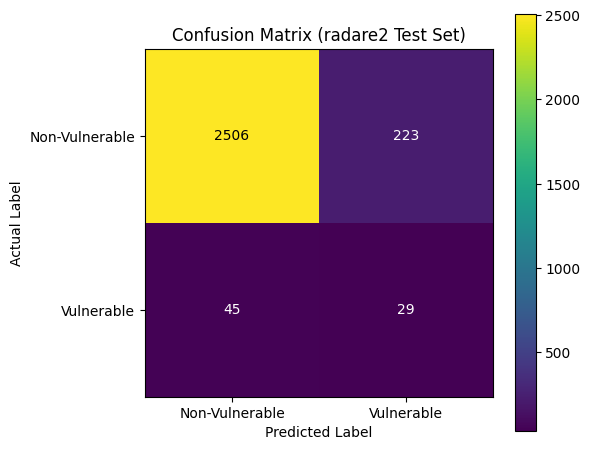

In [1]:
"""
Cross-Project Vulnerability Detection on PrimeVul
--------------------------------------------------
Train on ALL projects EXCEPT radare2 -> Test on radare2
SVMSMOTE Oversampling
"""

import os
import json
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    roc_auc_score, f1_score, confusion_matrix
)
from imblearn.over_sampling import SVMSMOTE
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# =========================================================
# Config
# =========================================================
SEED        = 42
TEST_PROJ   = "radare2"
COMBINED_FILE = "../../../../embedding/primevul/codebert/primevul_embedded.jsonl"
EMB_KEY     = "emb"
OUTPUT_DIR  = "results/svmsmote/radare2"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = "mps"
    torch.mps.manual_seed(SEED)
elif torch.cuda.is_available():
    DEVICE = "cuda"
    torch.cuda.manual_seed_all(SEED)
else:
    DEVICE = "cpu"


# =========================================================
# Data Loading
# =========================================================
def load_jsonl(path):
    records = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    X        = np.array([r[EMB_KEY]   for r in records], dtype=np.float32)
    y        = np.array([r["target"]  for r in records], dtype=np.int32)
    projects = np.array([r["project"] for r in records], dtype=object)
    return X, y, projects


# =========================================================
# Neural Network
# =========================================================
class VulnerabilityClassifier(nn.Module):
    def __init__(self, input_dim):
        super(VulnerabilityClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


# =========================================================
# Training Loop with Validation
# =========================================================
def train_neural_network(model, dataloader, x_val, y_val,
                          optimizer, criterion, epochs, desc):
    for epoch in tqdm(range(epochs), desc=desc, leave=False):
        model.train()
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(x_batch).squeeze(), y_batch)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(x_val).squeeze(), y_val).item()
        print(f"      {desc} | Epoch {epoch+1}/{epochs} - val_loss: {val_loss:.4f}")

    return model


# =========================================================
# Semi-supervised Transfer Learning
# =========================================================
def semi_supervised_transfer_learning(x_train, y_train, x_test, iteration):
    x_tr, x_val, y_tr, y_val = train_test_split(
        x_train, y_train,
        test_size=0.2,
        random_state=SEED
    )

    x_tr_t   = torch.tensor(x_tr,   dtype=torch.float32)
    y_tr_t   = torch.tensor(y_tr,   dtype=torch.float32)
    x_val_t  = torch.tensor(x_val,  dtype=torch.float32).to(DEVICE)
    y_val_t  = torch.tensor(y_val,  dtype=torch.float32).to(DEVICE)
    x_test_t = torch.tensor(x_test, dtype=torch.float32)

    dataset    = TensorDataset(x_tr_t, y_tr_t)
    dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

    model     = VulnerabilityClassifier(x_train.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
    criterion = nn.BCELoss()

    # Phase 1: Train on SVMSMOTE-oversampled source (all-except-radare2)
    model = train_neural_network(
        model, dataloader, x_val_t, y_val_t,
        optimizer, criterion,
        epochs=50,
        desc=f"Iter {iteration} - Phase 1"
    )

    # Pseudo-label the test set (radare2)
    model.eval()
    with torch.no_grad():
        y_pred        = model(x_test_t.to(DEVICE)).squeeze().cpu().numpy()
        y_pred_binary = (y_pred > 0.5).astype(int)

    # Phase 2: Fine-tune on source + pseudo-labelled radare2
    x_train_aug    = np.concatenate((x_train, x_test))
    y_train_aug    = np.concatenate((y_train, y_pred_binary))
    x_aug_t        = torch.tensor(x_train_aug, dtype=torch.float32)
    y_aug_t        = torch.tensor(y_train_aug, dtype=torch.float32)
    x_aug_val_t    = torch.tensor(x_val, dtype=torch.float32).to(DEVICE)
    y_aug_val_t    = torch.tensor(y_val, dtype=torch.float32).to(DEVICE)
    dataset_aug    = TensorDataset(x_aug_t, y_aug_t)
    dataloader_aug = DataLoader(dataset_aug, batch_size=32, shuffle=True)

    model = train_neural_network(
        model, dataloader_aug, x_aug_val_t, y_aug_val_t,
        optimizer, criterion,
        epochs=30,
        desc=f"Iter {iteration} - Phase 2"
    )

    model.eval()
    with torch.no_grad():
        y_pred_final = model(x_test_t.to(DEVICE)).squeeze().cpu().numpy()

    return model, y_pred_final


# =========================================================
# XGBoost
# =========================================================
def train_base_model_xgb(x_train, y_train, sample_weights=None):
    model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        eval_metric='logloss',
        random_state=SEED
    )
    model.fit(x_train, y_train, sample_weight=sample_weights)
    return model


# =========================================================
# Confusion Matrix Plot
# =========================================================
def plot_confusion_matrix(tn, fp, fn, tp, save_path):
    cm = np.array([[tn, fp],
                   [fn, tp]])

    fig, ax = plt.subplots(figsize=(6, 5))
    img = ax.imshow(cm, interpolation='nearest')
    ax.set_title("Confusion Matrix (radare2 Test Set)")
    plt.colorbar(img, ax=ax)

    tick_marks = np.arange(2)
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(["Non-Vulnerable", "Vulnerable"])
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(["Non-Vulnerable", "Vulnerable"])

    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            color = "black" if cm[i, j] > thresh else "white"
            ax.text(j, i, cm[i, j], ha="center", va="center", color=color)

    ax.set_ylabel("Actual Label")
    ax.set_xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    print(f"Confusion matrix saved as {save_path}")
    plt.show()


# =========================================================
# Main
# =========================================================
def main():
    print(f"\n=== PrimeVul | Train on ALL except radare2 -> Test on radare2 (SVMSMOTE) ===")
    print(f"    Device: {DEVICE}")

    # ----------------------------------------------------------
    # [1/5] Load combined embeddings and split by project
    # ----------------------------------------------------------
    print("\n[1/5] Loading combined embeddings...")

    X_all, y_all, proj_all = load_jsonl(COMBINED_FILE)

    train_mask = proj_all != TEST_PROJ
    train_emb  = X_all[train_mask].astype(np.float32)
    train_lbl  = y_all[train_mask].astype(np.int32)

    test_mask = proj_all == TEST_PROJ
    test_emb  = X_all[test_mask].astype(np.float32)
    test_lbl  = y_all[test_mask].astype(np.int32)

    if train_emb.shape[0] == 0:
        raise ValueError("Training pool is empty. Check COMBINED_FILE path.")
    if test_emb.shape[0] == 0:
        raise ValueError(f"No samples found for '{TEST_PROJ}' in {COMBINED_FILE}.")

    print(f"      Training pool             : {train_emb.shape}  "
          f"vuln={train_lbl.sum()}  benign={int((train_lbl == 0).sum())}")
    print(f"      Projects in training pool : {len(set(proj_all[train_mask]))}")
    print(f"      Test set (radare2)          : {test_emb.shape}  "
          f"vuln={test_lbl.sum()}  benign={int((test_lbl == 0).sum())}")
    print(f"      Training imbalance ratio  : {train_lbl.sum() / len(train_lbl):.4f}")

    # ----------------------------------------------------------
    # [2/5] Normalize
    # ----------------------------------------------------------
    print("\n[2/5] Normalizing embeddings...")
    scaler    = StandardScaler()
    train_emb = scaler.fit_transform(train_emb).astype(np.float32)
    test_emb  = scaler.transform(test_emb).astype(np.float32)

    # ----------------------------------------------------------
    # [3/5] Apply SVMSMOTE to training pool only
    # ----------------------------------------------------------
    print("\n[3/5] Applying SVMSMOTE...")
    svmsmote                        = SVMSMOTE(random_state=SEED)
    train_emb_svm, train_lbl_svm    = svmsmote.fit_resample(train_emb, train_lbl)
    train_emb_svm                   = train_emb_svm.astype(np.float32)
    train_lbl_svm                   = train_lbl_svm.astype(np.int32)
    print(f"      Before SVMSMOTE : {train_emb.shape}  "
          f"vuln={train_lbl.sum()}  benign={int((train_lbl == 0).sum())}")
    print(f"      After SVMSMOTE  : {train_emb_svm.shape}  "
          f"vuln={train_lbl_svm.sum()}  benign={int((train_lbl_svm == 0).sum())}")

    # ----------------------------------------------------------
    # [4/5] Ensemble (NN + XGBoost) x 3 iterations
    # ----------------------------------------------------------
    print("\n[4/5] Running ensemble iterations...")
    num_iterations       = 3
    ensemble_predictions = np.zeros(len(test_lbl))

    for i in tqdm(range(num_iterations), desc="Ensemble", unit="iter"):
        print(f"\n      [Iteration {i+1}/{num_iterations}] Training neural network...")
        model_nn, _ = semi_supervised_transfer_learning(
            train_emb_svm, train_lbl_svm,
            test_emb,
            iteration=i+1
        )

        print(f"      [Iteration {i+1}/{num_iterations}] Training XGBoost...")
        model_nn.eval()
        with torch.no_grad():
            x_tr_t       = torch.tensor(train_emb_svm, dtype=torch.float32).to(DEVICE)
            y_train_pred = model_nn(x_tr_t).squeeze().cpu().numpy()

        sample_weights        = np.where(train_lbl_svm == 1, y_train_pred, 1 - y_train_pred)
        model_xgb             = train_base_model_xgb(train_emb_svm, train_lbl_svm, sample_weights)
        model_xgb_pred        = model_xgb.predict_proba(test_emb)[:, 1]
        ensemble_predictions += model_xgb_pred
        print(f"      [Iteration {i+1}/{num_iterations}] Done")

    # ----------------------------------------------------------
    # [5/5] Metrics
    # ----------------------------------------------------------
    print("\n[5/5] Computing metrics...")
    ensemble_avg = ensemble_predictions / num_iterations
    y_pred_final = (ensemble_avg > 0.5).astype(int)

    accuracy  = accuracy_score(test_lbl,  y_pred_final)
    recall    = recall_score(test_lbl,    y_pred_final, zero_division=0)
    precision = precision_score(test_lbl, y_pred_final, zero_division=0)
    auc       = roc_auc_score(test_lbl,   ensemble_avg)
    f1        = f1_score(test_lbl,        y_pred_final, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(test_lbl, y_pred_final).ravel()
    g_mean = np.sqrt((tp / (tp + fn + 1e-9)) * (tn / (tn + fp + 1e-9)))
    pf     = fp / (fp + tn + 1e-9)

    print("\n=== Evaluation Results (radare2 Test Set) ===")
    print(f"Accuracy  : {accuracy:.3f}")
    print(f"Precision : {precision:.3f}")
    print(f"Recall    : {recall:.3f}")
    print(f"F1-score  : {f1:.3f}")
    print(f"AUC       : {auc:.3f}")
    print(f"G-mean    : {g_mean:.3f}")
    print(f"PF value  : {pf:.3f}")
    print("\nConfusion Matrix:")
    print(f"  TN: {tn}  FP: {fp}")
    print(f"  FN: {fn}  TP: {tp}")

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    results = {
        "experiment"          : "svmsmote",
        "train"               : "all_except_radare2",
        "test"                : "radare2",
        "n_train_projects"    : int(len(set(proj_all[train_mask]))),
        "n_train_samples"     : int(len(train_lbl)),
        "n_train_svmsmote"    : int(len(train_lbl_svm)),
        "n_test_samples"      : int(len(test_lbl)),
        "n_vuln_train"        : int(train_lbl.sum()),
        "n_vuln_train_svmsmote": int(train_lbl_svm.sum()),
        "n_vuln_test"         : int(test_lbl.sum()),
        "accuracy"            : round(float(accuracy),  4),
        "precision"           : round(float(precision), 4),
        "recall"              : round(float(recall),    4),
        "f1"                  : round(float(f1),        4),
        "auc"                 : round(float(auc),        4),
        "g_mean"              : round(float(g_mean),    4),
        "pf"                  : round(float(pf),        4),
        "confusion_matrix"    : {
            "tn": int(tn), "fp": int(fp),
            "fn": int(fn), "tp": int(tp)
        }
    }

    json_path = os.path.join(OUTPUT_DIR, "svmsmote_radare2.json")
    with open(json_path, "w") as f:
        json.dump(results, f, indent=2)
    print(f"\nResults saved to {json_path}")

    cm_path = os.path.join(OUTPUT_DIR, "confusion_matrix_svmsmote_radare2.png")
    plot_confusion_matrix(tn, fp, fn, tp, cm_path)


if __name__ == "__main__":
    main()


=== PrimeVul | Train on ALL except linux-2.6 -> Test on linux-2.6 (SVMSMOTE) ===
    Device: mps

[1/5] Loading combined embeddings...
      Training pool             : (221163, 768)  vuln=5904  benign=215259
      Projects in training pool : 753
      Test set (linux-2.6)          : (3370, 768)  vuln=100  benign=3270
      Training imbalance ratio  : 0.0267

[2/5] Normalizing embeddings...

[3/5] Applying SVMSMOTE...
      Before SVMSMOTE : (221163, 768)  vuln=5904  benign=215259
      After SVMSMOTE  : (430518, 768)  vuln=215259  benign=215259

[4/5] Running ensemble iterations...


Ensemble:   0%|          | 0/3 [00:00<?, ?iter/s]


      [Iteration 1/3] Training neural network...


Iter 1 - Phase 1:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 1 - Phase 1 | Epoch 1/50 - val_loss: 0.3738
      Iter 1 - Phase 1 | Epoch 2/50 - val_loss: 0.3398
      Iter 1 - Phase 1 | Epoch 3/50 - val_loss: 0.3186
      Iter 1 - Phase 1 | Epoch 4/50 - val_loss: 0.3030
      Iter 1 - Phase 1 | Epoch 5/50 - val_loss: 0.2867
      Iter 1 - Phase 1 | Epoch 6/50 - val_loss: 0.2721
      Iter 1 - Phase 1 | Epoch 7/50 - val_loss: 0.2589
      Iter 1 - Phase 1 | Epoch 8/50 - val_loss: 0.2470
      Iter 1 - Phase 1 | Epoch 9/50 - val_loss: 0.2342
      Iter 1 - Phase 1 | Epoch 10/50 - val_loss: 0.2232
      Iter 1 - Phase 1 | Epoch 11/50 - val_loss: 0.2112
      Iter 1 - Phase 1 | Epoch 12/50 - val_loss: 0.1998
      Iter 1 - Phase 1 | Epoch 13/50 - val_loss: 0.1908
      Iter 1 - Phase 1 | Epoch 14/50 - val_loss: 0.1811
      Iter 1 - Phase 1 | Epoch 15/50 - val_loss: 0.1726
      Iter 1 - Phase 1 | Epoch 16/50 - val_loss: 0.1686
      Iter 1 - Phase 1 | Epoch 17/50 - val_loss: 0.1583
      Iter 1 - Phase 1 | Epoch 18/50 - val_loss: 0.1546
 

...

      Iter 2 - Phase 2 | Epoch 1/30 - val_loss: 0.0795
      Iter 2 - Phase 2 | Epoch 2/30 - val_loss: 0.0781
      Iter 2 - Phase 2 | Epoch 3/30 - val_loss: 0.0734
      Iter 2 - Phase 2 | Epoch 4/30 - val_loss: 0.0708
      Iter 2 - Phase 2 | Epoch 5/30 - val_loss: 0.0745
      Iter 2 - Phase 2 | Epoch 6/30 - val_loss: 0.0706
      Iter 2 - Phase 2 | Epoch 7/30 - val_loss: 0.0682
      Iter 2 - Phase 2 | Epoch 8/30 - val_loss: 0.0676
      Iter 2 - Phase 2 | Epoch 9/30 - val_loss: 0.0665
      Iter 2 - Phase 2 | Epoch 10/30 - val_loss: 0.0649
      Iter 2 - Phase 2 | Epoch 11/30 - val_loss: 0.0654
      Iter 2 - Phase 2 | Epoch 12/30 - val_loss: 0.0647
      Iter 2 - Phase 2 | Epoch 13/30 - val_loss: 0.0636
      Iter 2 - Phase 2 | Epoch 14/30 - val_loss: 0.0605
      Iter 2 - Phase 2 | Epoch 15/30 - val_loss: 0.0604
      Iter 2 - Phase 2 | Epoch 16/30 - val_loss: 0.0616
      Iter 2 - Phase 2 | Epoch 17/30 - val_loss: 0.0604
      Iter 2 - Phase 2 | Epoch 18/30 - val_loss: 0.0604
 

Iter 3 - Phase 1:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 3 - Phase 1 | Epoch 1/50 - val_loss: 0.3637
      Iter 3 - Phase 1 | Epoch 2/50 - val_loss: 0.3334
      Iter 3 - Phase 1 | Epoch 3/50 - val_loss: 0.3120
      Iter 3 - Phase 1 | Epoch 4/50 - val_loss: 0.2968
      Iter 3 - Phase 1 | Epoch 5/50 - val_loss: 0.2824
      Iter 3 - Phase 1 | Epoch 6/50 - val_loss: 0.2690
      Iter 3 - Phase 1 | Epoch 7/50 - val_loss: 0.2568
      Iter 3 - Phase 1 | Epoch 8/50 - val_loss: 0.2431
      Iter 3 - Phase 1 | Epoch 9/50 - val_loss: 0.2312
      Iter 3 - Phase 1 | Epoch 10/50 - val_loss: 0.2258
      Iter 3 - Phase 1 | Epoch 11/50 - val_loss: 0.2081
      Iter 3 - Phase 1 | Epoch 12/50 - val_loss: 0.1981
      Iter 3 - Phase 1 | Epoch 13/50 - val_loss: 0.1918
      Iter 3 - Phase 1 | Epoch 14/50 - val_loss: 0.1813
      Iter 3 - Phase 1 | Epoch 15/50 - val_loss: 0.1714
      Iter 3 - Phase 1 | Epoch 16/50 - val_loss: 0.1640
      Iter 3 - Phase 1 | Epoch 17/50 - val_loss: 0.1561
      Iter 3 - Phase 1 | Epoch 18/50 - val_loss: 0.1521
 

Iter 3 - Phase 2:   0%|          | 0/30 [00:00<?, ?it/s]

      Iter 3 - Phase 2 | Epoch 1/30 - val_loss: 0.0821
      Iter 3 - Phase 2 | Epoch 2/30 - val_loss: 0.0823
      Iter 3 - Phase 2 | Epoch 3/30 - val_loss: 0.0776
      Iter 3 - Phase 2 | Epoch 4/30 - val_loss: 0.0765
      Iter 3 - Phase 2 | Epoch 5/30 - val_loss: 0.0751
      Iter 3 - Phase 2 | Epoch 6/30 - val_loss: 0.0764
      Iter 3 - Phase 2 | Epoch 7/30 - val_loss: 0.0727
      Iter 3 - Phase 2 | Epoch 8/30 - val_loss: 0.0685
      Iter 3 - Phase 2 | Epoch 9/30 - val_loss: 0.0733
      Iter 3 - Phase 2 | Epoch 10/30 - val_loss: 0.0671
      Iter 3 - Phase 2 | Epoch 11/30 - val_loss: 0.0656
      Iter 3 - Phase 2 | Epoch 12/30 - val_loss: 0.0639
      Iter 3 - Phase 2 | Epoch 13/30 - val_loss: 0.0622
      Iter 3 - Phase 2 | Epoch 14/30 - val_loss: 0.0606
      Iter 3 - Phase 2 | Epoch 15/30 - val_loss: 0.0605
      Iter 3 - Phase 2 | Epoch 16/30 - val_loss: 0.0595
      Iter 3 - Phase 2 | Epoch 17/30 - val_loss: 0.0585
      Iter 3 - Phase 2 | Epoch 18/30 - val_loss: 0.0585
 

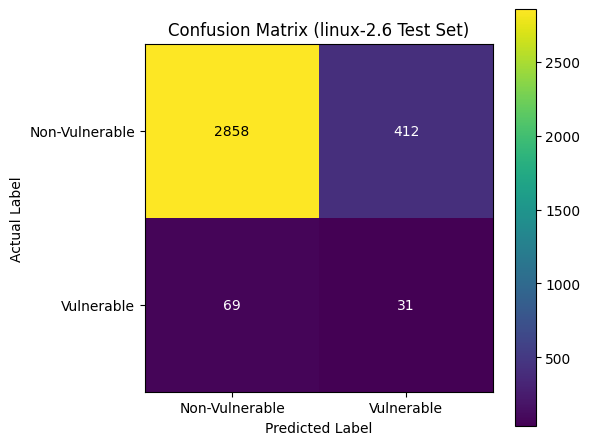

In [2]:
"""
Cross-Project Vulnerability Detection on PrimeVul
--------------------------------------------------
Train on ALL projects EXCEPT linux-2.6 -> Test on linux-2.6
SVMSMOTE Oversampling
"""

import os
import json
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    roc_auc_score, f1_score, confusion_matrix
)
from imblearn.over_sampling import SVMSMOTE
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# =========================================================
# Config
# =========================================================
SEED        = 42
TEST_PROJ   = "linux-2.6"
COMBINED_FILE = "../../../../embedding/primevul/codebert/primevul_embedded.jsonl"
EMB_KEY     = "emb"
OUTPUT_DIR  = "results/svmsmote/linux-2.6"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = "mps"
    torch.mps.manual_seed(SEED)
elif torch.cuda.is_available():
    DEVICE = "cuda"
    torch.cuda.manual_seed_all(SEED)
else:
    DEVICE = "cpu"


# =========================================================
# Data Loading
# =========================================================
def load_jsonl(path):
    records = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    X        = np.array([r[EMB_KEY]   for r in records], dtype=np.float32)
    y        = np.array([r["target"]  for r in records], dtype=np.int32)
    projects = np.array([r["project"] for r in records], dtype=object)
    return X, y, projects


# =========================================================
# Neural Network
# =========================================================
class VulnerabilityClassifier(nn.Module):
    def __init__(self, input_dim):
        super(VulnerabilityClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


# =========================================================
# Training Loop with Validation
# =========================================================
def train_neural_network(model, dataloader, x_val, y_val,
                          optimizer, criterion, epochs, desc):
    for epoch in tqdm(range(epochs), desc=desc, leave=False):
        model.train()
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(x_batch).squeeze(), y_batch)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(x_val).squeeze(), y_val).item()
        print(f"      {desc} | Epoch {epoch+1}/{epochs} - val_loss: {val_loss:.4f}")

    return model


# =========================================================
# Semi-supervised Transfer Learning
# =========================================================
def semi_supervised_transfer_learning(x_train, y_train, x_test, iteration):
    x_tr, x_val, y_tr, y_val = train_test_split(
        x_train, y_train,
        test_size=0.2,
        random_state=SEED
    )

    x_tr_t   = torch.tensor(x_tr,   dtype=torch.float32)
    y_tr_t   = torch.tensor(y_tr,   dtype=torch.float32)
    x_val_t  = torch.tensor(x_val,  dtype=torch.float32).to(DEVICE)
    y_val_t  = torch.tensor(y_val,  dtype=torch.float32).to(DEVICE)
    x_test_t = torch.tensor(x_test, dtype=torch.float32)

    dataset    = TensorDataset(x_tr_t, y_tr_t)
    dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

    model     = VulnerabilityClassifier(x_train.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
    criterion = nn.BCELoss()

    # Phase 1: Train on SVMSMOTE-oversampled source (all-except-linux-2.6)
    model = train_neural_network(
        model, dataloader, x_val_t, y_val_t,
        optimizer, criterion,
        epochs=50,
        desc=f"Iter {iteration} - Phase 1"
    )

    # Pseudo-label the test set (linux-2.6)
    model.eval()
    with torch.no_grad():
        y_pred        = model(x_test_t.to(DEVICE)).squeeze().cpu().numpy()
        y_pred_binary = (y_pred > 0.5).astype(int)

    # Phase 2: Fine-tune on source + pseudo-labelled linux-2.6
    x_train_aug    = np.concatenate((x_train, x_test))
    y_train_aug    = np.concatenate((y_train, y_pred_binary))
    x_aug_t        = torch.tensor(x_train_aug, dtype=torch.float32)
    y_aug_t        = torch.tensor(y_train_aug, dtype=torch.float32)
    x_aug_val_t    = torch.tensor(x_val, dtype=torch.float32).to(DEVICE)
    y_aug_val_t    = torch.tensor(y_val, dtype=torch.float32).to(DEVICE)
    dataset_aug    = TensorDataset(x_aug_t, y_aug_t)
    dataloader_aug = DataLoader(dataset_aug, batch_size=32, shuffle=True)

    model = train_neural_network(
        model, dataloader_aug, x_aug_val_t, y_aug_val_t,
        optimizer, criterion,
        epochs=30,
        desc=f"Iter {iteration} - Phase 2"
    )

    model.eval()
    with torch.no_grad():
        y_pred_final = model(x_test_t.to(DEVICE)).squeeze().cpu().numpy()

    return model, y_pred_final


# =========================================================
# XGBoost
# =========================================================
def train_base_model_xgb(x_train, y_train, sample_weights=None):
    model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        eval_metric='logloss',
        random_state=SEED
    )
    model.fit(x_train, y_train, sample_weight=sample_weights)
    return model


# =========================================================
# Confusion Matrix Plot
# =========================================================
def plot_confusion_matrix(tn, fp, fn, tp, save_path):
    cm = np.array([[tn, fp],
                   [fn, tp]])

    fig, ax = plt.subplots(figsize=(6, 5))
    img = ax.imshow(cm, interpolation='nearest')
    ax.set_title("Confusion Matrix (linux-2.6 Test Set)")
    plt.colorbar(img, ax=ax)

    tick_marks = np.arange(2)
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(["Non-Vulnerable", "Vulnerable"])
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(["Non-Vulnerable", "Vulnerable"])

    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            color = "black" if cm[i, j] > thresh else "white"
            ax.text(j, i, cm[i, j], ha="center", va="center", color=color)

    ax.set_ylabel("Actual Label")
    ax.set_xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    print(f"Confusion matrix saved as {save_path}")
    plt.show()


# =========================================================
# Main
# =========================================================
def main():
    print(f"\n=== PrimeVul | Train on ALL except linux-2.6 -> Test on linux-2.6 (SVMSMOTE) ===")
    print(f"    Device: {DEVICE}")

    # ----------------------------------------------------------
    # [1/5] Load combined embeddings and split by project
    # ----------------------------------------------------------
    print("\n[1/5] Loading combined embeddings...")

    X_all, y_all, proj_all = load_jsonl(COMBINED_FILE)

    train_mask = proj_all != TEST_PROJ
    train_emb  = X_all[train_mask].astype(np.float32)
    train_lbl  = y_all[train_mask].astype(np.int32)

    test_mask = proj_all == TEST_PROJ
    test_emb  = X_all[test_mask].astype(np.float32)
    test_lbl  = y_all[test_mask].astype(np.int32)

    if train_emb.shape[0] == 0:
        raise ValueError("Training pool is empty. Check COMBINED_FILE path.")
    if test_emb.shape[0] == 0:
        raise ValueError(f"No samples found for '{TEST_PROJ}' in {COMBINED_FILE}.")

    print(f"      Training pool             : {train_emb.shape}  "
          f"vuln={train_lbl.sum()}  benign={int((train_lbl == 0).sum())}")
    print(f"      Projects in training pool : {len(set(proj_all[train_mask]))}")
    print(f"      Test set (linux-2.6)          : {test_emb.shape}  "
          f"vuln={test_lbl.sum()}  benign={int((test_lbl == 0).sum())}")
    print(f"      Training imbalance ratio  : {train_lbl.sum() / len(train_lbl):.4f}")

    # ----------------------------------------------------------
    # [2/5] Normalize
    # ----------------------------------------------------------
    print("\n[2/5] Normalizing embeddings...")
    scaler    = StandardScaler()
    train_emb = scaler.fit_transform(train_emb).astype(np.float32)
    test_emb  = scaler.transform(test_emb).astype(np.float32)

    # ----------------------------------------------------------
    # [3/5] Apply SVMSMOTE to training pool only
    # ----------------------------------------------------------
    print("\n[3/5] Applying SVMSMOTE...")
    svmsmote                        = SVMSMOTE(random_state=SEED)
    train_emb_svm, train_lbl_svm    = svmsmote.fit_resample(train_emb, train_lbl)
    train_emb_svm                   = train_emb_svm.astype(np.float32)
    train_lbl_svm                   = train_lbl_svm.astype(np.int32)
    print(f"      Before SVMSMOTE : {train_emb.shape}  "
          f"vuln={train_lbl.sum()}  benign={int((train_lbl == 0).sum())}")
    print(f"      After SVMSMOTE  : {train_emb_svm.shape}  "
          f"vuln={train_lbl_svm.sum()}  benign={int((train_lbl_svm == 0).sum())}")

    # ----------------------------------------------------------
    # [4/5] Ensemble (NN + XGBoost) x 3 iterations
    # ----------------------------------------------------------
    print("\n[4/5] Running ensemble iterations...")
    num_iterations       = 3
    ensemble_predictions = np.zeros(len(test_lbl))

    for i in tqdm(range(num_iterations), desc="Ensemble", unit="iter"):
        print(f"\n      [Iteration {i+1}/{num_iterations}] Training neural network...")
        model_nn, _ = semi_supervised_transfer_learning(
            train_emb_svm, train_lbl_svm,
            test_emb,
            iteration=i+1
        )

        print(f"      [Iteration {i+1}/{num_iterations}] Training XGBoost...")
        model_nn.eval()
        with torch.no_grad():
            x_tr_t       = torch.tensor(train_emb_svm, dtype=torch.float32).to(DEVICE)
            y_train_pred = model_nn(x_tr_t).squeeze().cpu().numpy()

        sample_weights        = np.where(train_lbl_svm == 1, y_train_pred, 1 - y_train_pred)
        model_xgb             = train_base_model_xgb(train_emb_svm, train_lbl_svm, sample_weights)
        model_xgb_pred        = model_xgb.predict_proba(test_emb)[:, 1]
        ensemble_predictions += model_xgb_pred
        print(f"      [Iteration {i+1}/{num_iterations}] Done")

    # ----------------------------------------------------------
    # [5/5] Metrics
    # ----------------------------------------------------------
    print("\n[5/5] Computing metrics...")
    ensemble_avg = ensemble_predictions / num_iterations
    y_pred_final = (ensemble_avg > 0.5).astype(int)

    accuracy  = accuracy_score(test_lbl,  y_pred_final)
    recall    = recall_score(test_lbl,    y_pred_final, zero_division=0)
    precision = precision_score(test_lbl, y_pred_final, zero_division=0)
    auc       = roc_auc_score(test_lbl,   ensemble_avg)
    f1        = f1_score(test_lbl,        y_pred_final, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(test_lbl, y_pred_final).ravel()
    g_mean = np.sqrt((tp / (tp + fn + 1e-9)) * (tn / (tn + fp + 1e-9)))
    pf     = fp / (fp + tn + 1e-9)

    print("\n=== Evaluation Results (linux-2.6 Test Set) ===")
    print(f"Accuracy  : {accuracy:.3f}")
    print(f"Precision : {precision:.3f}")
    print(f"Recall    : {recall:.3f}")
    print(f"F1-score  : {f1:.3f}")
    print(f"AUC       : {auc:.3f}")
    print(f"G-mean    : {g_mean:.3f}")
    print(f"PF value  : {pf:.3f}")
    print("\nConfusion Matrix:")
    print(f"  TN: {tn}  FP: {fp}")
    print(f"  FN: {fn}  TP: {tp}")

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    results = {
        "experiment"          : "svmsmote",
        "train"               : "all_except_linux-2.6",
        "test"                : "linux-2.6",
        "n_train_projects"    : int(len(set(proj_all[train_mask]))),
        "n_train_samples"     : int(len(train_lbl)),
        "n_train_svmsmote"    : int(len(train_lbl_svm)),
        "n_test_samples"      : int(len(test_lbl)),
        "n_vuln_train"        : int(train_lbl.sum()),
        "n_vuln_train_svmsmote": int(train_lbl_svm.sum()),
        "n_vuln_test"         : int(test_lbl.sum()),
        "accuracy"            : round(float(accuracy),  4),
        "precision"           : round(float(precision), 4),
        "recall"              : round(float(recall),    4),
        "f1"                  : round(float(f1),        4),
        "auc"                 : round(float(auc),        4),
        "g_mean"              : round(float(g_mean),    4),
        "pf"                  : round(float(pf),        4),
        "confusion_matrix"    : {
            "tn": int(tn), "fp": int(fp),
            "fn": int(fn), "tp": int(tp)
        }
    }

    json_path = os.path.join(OUTPUT_DIR, "svmsmote_linux-2.6.json")
    with open(json_path, "w") as f:
        json.dump(results, f, indent=2)
    print(f"\nResults saved to {json_path}")

    cm_path = os.path.join(OUTPUT_DIR, "confusion_matrix_svmsmote_linux-2.6.png")
    plot_confusion_matrix(tn, fp, fn, tp, cm_path)


if __name__ == "__main__":
    main()

In [ ]:
"""
Cross-Project Vulnerability Detection on PrimeVul
--------------------------------------------------
Train on ALL projects EXCEPT vim -> Test on vim
SVMSMOTE Oversampling
"""

import os
import json
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    roc_auc_score, f1_score, confusion_matrix
)
from imblearn.over_sampling import SVMSMOTE
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# =========================================================
# Config
# =========================================================
SEED        = 42
TEST_PROJ   = "vim"
COMBINED_FILE = "../../../../embedding/primevul/codebert/primevul_embedded.jsonl"
EMB_KEY     = "emb"
OUTPUT_DIR  = "results/svmsmote/vim"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = "mps"
    torch.mps.manual_seed(SEED)
elif torch.cuda.is_available():
    DEVICE = "cuda"
    torch.cuda.manual_seed_all(SEED)
else:
    DEVICE = "cpu"


# =========================================================
# Data Loading
# =========================================================
def load_jsonl(path):
    records = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    X        = np.array([r[EMB_KEY]   for r in records], dtype=np.float32)
    y        = np.array([r["target"]  for r in records], dtype=np.int32)
    projects = np.array([r["project"] for r in records], dtype=object)
    return X, y, projects


# =========================================================
# Neural Network
# =========================================================
class VulnerabilityClassifier(nn.Module):
    def __init__(self, input_dim):
        super(VulnerabilityClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


# =========================================================
# Training Loop with Validation
# =========================================================
def train_neural_network(model, dataloader, x_val, y_val,
                          optimizer, criterion, epochs, desc):
    for epoch in tqdm(range(epochs), desc=desc, leave=False):
        model.train()
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(x_batch).squeeze(), y_batch)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(x_val).squeeze(), y_val).item()
        print(f"      {desc} | Epoch {epoch+1}/{epochs} - val_loss: {val_loss:.4f}")

    return model


# =========================================================
# Semi-supervised Transfer Learning
# =========================================================
def semi_supervised_transfer_learning(x_train, y_train, x_test, iteration):
    x_tr, x_val, y_tr, y_val = train_test_split(
        x_train, y_train,
        test_size=0.2,
        random_state=SEED
    )

    x_tr_t   = torch.tensor(x_tr,   dtype=torch.float32)
    y_tr_t   = torch.tensor(y_tr,   dtype=torch.float32)
    x_val_t  = torch.tensor(x_val,  dtype=torch.float32).to(DEVICE)
    y_val_t  = torch.tensor(y_val,  dtype=torch.float32).to(DEVICE)
    x_test_t = torch.tensor(x_test, dtype=torch.float32)

    dataset    = TensorDataset(x_tr_t, y_tr_t)
    dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

    model     = VulnerabilityClassifier(x_train.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
    criterion = nn.BCELoss()

    # Phase 1: Train on SVMSMOTE-oversampled source (all-except-vim)
    model = train_neural_network(
        model, dataloader, x_val_t, y_val_t,
        optimizer, criterion,
        epochs=50,
        desc=f"Iter {iteration} - Phase 1"
    )

    # Pseudo-label the test set (vim)
    model.eval()
    with torch.no_grad():
        y_pred        = model(x_test_t.to(DEVICE)).squeeze().cpu().numpy()
        y_pred_binary = (y_pred > 0.5).astype(int)

    # Phase 2: Fine-tune on source + pseudo-labelled vim
    x_train_aug    = np.concatenate((x_train, x_test))
    y_train_aug    = np.concatenate((y_train, y_pred_binary))
    x_aug_t        = torch.tensor(x_train_aug, dtype=torch.float32)
    y_aug_t        = torch.tensor(y_train_aug, dtype=torch.float32)
    x_aug_val_t    = torch.tensor(x_val, dtype=torch.float32).to(DEVICE)
    y_aug_val_t    = torch.tensor(y_val, dtype=torch.float32).to(DEVICE)
    dataset_aug    = TensorDataset(x_aug_t, y_aug_t)
    dataloader_aug = DataLoader(dataset_aug, batch_size=32, shuffle=True)

    model = train_neural_network(
        model, dataloader_aug, x_aug_val_t, y_aug_val_t,
        optimizer, criterion,
        epochs=30,
        desc=f"Iter {iteration} - Phase 2"
    )

    model.eval()
    with torch.no_grad():
        y_pred_final = model(x_test_t.to(DEVICE)).squeeze().cpu().numpy()

    return model, y_pred_final


# =========================================================
# XGBoost
# =========================================================
def train_base_model_xgb(x_train, y_train, sample_weights=None):
    model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        eval_metric='logloss',
        random_state=SEED
    )
    model.fit(x_train, y_train, sample_weight=sample_weights)
    return model


# =========================================================
# Confusion Matrix Plot
# =========================================================
def plot_confusion_matrix(tn, fp, fn, tp, save_path):
    cm = np.array([[tn, fp],
                   [fn, tp]])

    fig, ax = plt.subplots(figsize=(6, 5))
    img = ax.imshow(cm, interpolation='nearest')
    ax.set_title("Confusion Matrix (vim Test Set)")
    plt.colorbar(img, ax=ax)

    tick_marks = np.arange(2)
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(["Non-Vulnerable", "Vulnerable"])
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(["Non-Vulnerable", "Vulnerable"])

    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            color = "black" if cm[i, j] > thresh else "white"
            ax.text(j, i, cm[i, j], ha="center", va="center", color=color)

    ax.set_ylabel("Actual Label")
    ax.set_xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    print(f"Confusion matrix saved as {save_path}")
    plt.show()


# =========================================================
# Main
# =========================================================
def main():
    print(f"\n=== PrimeVul | Train on ALL except vim -> Test on vim (SVMSMOTE) ===")
    print(f"    Device: {DEVICE}")

    # ----------------------------------------------------------
    # [1/5] Load combined embeddings and split by project
    # ----------------------------------------------------------
    print("\n[1/5] Loading combined embeddings...")

    X_all, y_all, proj_all = load_jsonl(COMBINED_FILE)

    train_mask = proj_all != TEST_PROJ
    train_emb  = X_all[train_mask].astype(np.float32)
    train_lbl  = y_all[train_mask].astype(np.int32)

    test_mask = proj_all == TEST_PROJ
    test_emb  = X_all[test_mask].astype(np.float32)
    test_lbl  = y_all[test_mask].astype(np.int32)

    if train_emb.shape[0] == 0:
        raise ValueError("Training pool is empty. Check COMBINED_FILE path.")
    if test_emb.shape[0] == 0:
        raise ValueError(f"No samples found for '{TEST_PROJ}' in {COMBINED_FILE}.")

    print(f"      Training pool             : {train_emb.shape}  "
          f"vuln={train_lbl.sum()}  benign={int((train_lbl == 0).sum())}")
    print(f"      Projects in training pool : {len(set(proj_all[train_mask]))}")
    print(f"      Test set (vim)          : {test_emb.shape}  "
          f"vuln={test_lbl.sum()}  benign={int((test_lbl == 0).sum())}")
    print(f"      Training imbalance ratio  : {train_lbl.sum() / len(train_lbl):.4f}")

    # ----------------------------------------------------------
    # [2/5] Normalize
    # ----------------------------------------------------------
    print("\n[2/5] Normalizing embeddings...")
    scaler    = StandardScaler()
    train_emb = scaler.fit_transform(train_emb).astype(np.float32)
    test_emb  = scaler.transform(test_emb).astype(np.float32)

    # ----------------------------------------------------------
    # [3/5] Apply SVMSMOTE to training pool only
    # ----------------------------------------------------------
    print("\n[3/5] Applying SVMSMOTE...")
    svmsmote                        = SVMSMOTE(random_state=SEED)
    train_emb_svm, train_lbl_svm    = svmsmote.fit_resample(train_emb, train_lbl)
    train_emb_svm                   = train_emb_svm.astype(np.float32)
    train_lbl_svm                   = train_lbl_svm.astype(np.int32)
    print(f"      Before SVMSMOTE : {train_emb.shape}  "
          f"vuln={train_lbl.sum()}  benign={int((train_lbl == 0).sum())}")
    print(f"      After SVMSMOTE  : {train_emb_svm.shape}  "
          f"vuln={train_lbl_svm.sum()}  benign={int((train_lbl_svm == 0).sum())}")

    # ----------------------------------------------------------
    # [4/5] Ensemble (NN + XGBoost) x 3 iterations
    # ----------------------------------------------------------
    print("\n[4/5] Running ensemble iterations...")
    num_iterations       = 3
    ensemble_predictions = np.zeros(len(test_lbl))

    for i in tqdm(range(num_iterations), desc="Ensemble", unit="iter"):
        print(f"\n      [Iteration {i+1}/{num_iterations}] Training neural network...")
        model_nn, _ = semi_supervised_transfer_learning(
            train_emb_svm, train_lbl_svm,
            test_emb,
            iteration=i+1
        )

        print(f"      [Iteration {i+1}/{num_iterations}] Training XGBoost...")
        model_nn.eval()
        with torch.no_grad():
            x_tr_t       = torch.tensor(train_emb_svm, dtype=torch.float32).to(DEVICE)
            y_train_pred = model_nn(x_tr_t).squeeze().cpu().numpy()

        sample_weights        = np.where(train_lbl_svm == 1, y_train_pred, 1 - y_train_pred)
        model_xgb             = train_base_model_xgb(train_emb_svm, train_lbl_svm, sample_weights)
        model_xgb_pred        = model_xgb.predict_proba(test_emb)[:, 1]
        ensemble_predictions += model_xgb_pred
        print(f"      [Iteration {i+1}/{num_iterations}] Done")

    # ----------------------------------------------------------
    # [5/5] Metrics
    # ----------------------------------------------------------
    print("\n[5/5] Computing metrics...")
    ensemble_avg = ensemble_predictions / num_iterations
    y_pred_final = (ensemble_avg > 0.5).astype(int)

    accuracy  = accuracy_score(test_lbl,  y_pred_final)
    recall    = recall_score(test_lbl,    y_pred_final, zero_division=0)
    precision = precision_score(test_lbl, y_pred_final, zero_division=0)
    auc       = roc_auc_score(test_lbl,   ensemble_avg)
    f1        = f1_score(test_lbl,        y_pred_final, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(test_lbl, y_pred_final).ravel()
    g_mean = np.sqrt((tp / (tp + fn + 1e-9)) * (tn / (tn + fp + 1e-9)))
    pf     = fp / (fp + tn + 1e-9)

    print("\n=== Evaluation Results (vim Test Set) ===")
    print(f"Accuracy  : {accuracy:.3f}")
    print(f"Precision : {precision:.3f}")
    print(f"Recall    : {recall:.3f}")
    print(f"F1-score  : {f1:.3f}")
    print(f"AUC       : {auc:.3f}")
    print(f"G-mean    : {g_mean:.3f}")
    print(f"PF value  : {pf:.3f}")
    print("\nConfusion Matrix:")
    print(f"  TN: {tn}  FP: {fp}")
    print(f"  FN: {fn}  TP: {tp}")

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    results = {
        "experiment"          : "svmsmote",
        "train"               : "all_except_vim",
        "test"                : "vim",
        "n_train_projects"    : int(len(set(proj_all[train_mask]))),
        "n_train_samples"     : int(len(train_lbl)),
        "n_train_svmsmote"    : int(len(train_lbl_svm)),
        "n_test_samples"      : int(len(test_lbl)),
        "n_vuln_train"        : int(train_lbl.sum()),
        "n_vuln_train_svmsmote": int(train_lbl_svm.sum()),
        "n_vuln_test"         : int(test_lbl.sum()),
        "accuracy"            : round(float(accuracy),  4),
        "precision"           : round(float(precision), 4),
        "recall"              : round(float(recall),    4),
        "f1"                  : round(float(f1),        4),
        "auc"                 : round(float(auc),        4),
        "g_mean"              : round(float(g_mean),    4),
        "pf"                  : round(float(pf),        4),
        "confusion_matrix"    : {
            "tn": int(tn), "fp": int(fp),
            "fn": int(fn), "tp": int(tp)
        }
    }

    json_path = os.path.join(OUTPUT_DIR, "svmsmote_vim.json")
    with open(json_path, "w") as f:
        json.dump(results, f, indent=2)
    print(f"\nResults saved to {json_path}")

    cm_path = os.path.join(OUTPUT_DIR, "confusion_matrix_svmsmote_vim.png")
    plot_confusion_matrix(tn, fp, fn, tp, cm_path)


if __name__ == "__main__":
    main()


=== PrimeVul | Train on ALL except vim -> Test on vim (SVMSMOTE) ===
    Device: mps

[1/5] Loading combined embeddings...
      Training pool             : (221466, 768)  vuln=5898  benign=215568
      Projects in training pool : 753
      Test set (vim)          : (3067, 768)  vuln=106  benign=2961
      Training imbalance ratio  : 0.0266

[2/5] Normalizing embeddings...

[3/5] Applying SVMSMOTE...
      Before SVMSMOTE : (221466, 768)  vuln=5898  benign=215568
      After SVMSMOTE  : (431136, 768)  vuln=215568  benign=215568

[4/5] Running ensemble iterations...


Ensemble:   0%|          | 0/3 [00:00<?, ?iter/s]


      [Iteration 1/3] Training neural network...


Iter 1 - Phase 1:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 1 - Phase 1 | Epoch 1/50 - val_loss: 0.3741
      Iter 1 - Phase 1 | Epoch 2/50 - val_loss: 0.3415
      Iter 1 - Phase 1 | Epoch 3/50 - val_loss: 0.3173
      Iter 1 - Phase 1 | Epoch 4/50 - val_loss: 0.3015
      Iter 1 - Phase 1 | Epoch 5/50 - val_loss: 0.2850
      Iter 1 - Phase 1 | Epoch 6/50 - val_loss: 0.2705
      Iter 1 - Phase 1 | Epoch 7/50 - val_loss: 0.2573
      Iter 1 - Phase 1 | Epoch 8/50 - val_loss: 0.2439
      Iter 1 - Phase 1 | Epoch 9/50 - val_loss: 0.2319
      Iter 1 - Phase 1 | Epoch 10/50 - val_loss: 0.2226
      Iter 1 - Phase 1 | Epoch 11/50 - val_loss: 0.2076
      Iter 1 - Phase 1 | Epoch 12/50 - val_loss: 0.1982
      Iter 1 - Phase 1 | Epoch 13/50 - val_loss: 0.1888
      Iter 1 - Phase 1 | Epoch 14/50 - val_loss: 0.1800
      Iter 1 - Phase 1 | Epoch 15/50 - val_loss: 0.1722
      Iter 1 - Phase 1 | Epoch 16/50 - val_loss: 0.1642
      Iter 1 - Phase 1 | Epoch 17/50 - val_loss: 0.1585
      Iter 1 - Phase 1 | Epoch 18/50 - val_loss: 0.1517
 

...

      Iter 2 - Phase 1 | Epoch 1/50 - val_loss: 0.3655
      Iter 2 - Phase 1 | Epoch 2/50 - val_loss: 0.3293
      Iter 2 - Phase 1 | Epoch 3/50 - val_loss: 0.3075
      Iter 2 - Phase 1 | Epoch 4/50 - val_loss: 0.2901
      Iter 2 - Phase 1 | Epoch 5/50 - val_loss: 0.2732
      Iter 2 - Phase 1 | Epoch 6/50 - val_loss: 0.2584
      Iter 2 - Phase 1 | Epoch 7/50 - val_loss: 0.2449
      Iter 2 - Phase 1 | Epoch 8/50 - val_loss: 0.2320
      Iter 2 - Phase 1 | Epoch 9/50 - val_loss: 0.2192
      Iter 2 - Phase 1 | Epoch 10/50 - val_loss: 0.2092
      Iter 2 - Phase 1 | Epoch 11/50 - val_loss: 0.2004
      Iter 2 - Phase 1 | Epoch 12/50 - val_loss: 0.1919
      Iter 2 - Phase 1 | Epoch 13/50 - val_loss: 0.1793
      Iter 2 - Phase 1 | Epoch 14/50 - val_loss: 0.1715
      Iter 2 - Phase 1 | Epoch 15/50 - val_loss: 0.1641
      Iter 2 - Phase 1 | Epoch 16/50 - val_loss: 0.1588
      Iter 2 - Phase 1 | Epoch 17/50 - val_loss: 0.1518
      Iter 2 - Phase 1 | Epoch 18/50 - val_loss: 0.1456
 

Iter 2 - Phase 2:   0%|          | 0/30 [00:00<?, ?it/s]

      Iter 2 - Phase 2 | Epoch 1/30 - val_loss: 0.0811
      Iter 2 - Phase 2 | Epoch 2/30 - val_loss: 0.0772
      Iter 2 - Phase 2 | Epoch 3/30 - val_loss: 0.0744
      Iter 2 - Phase 2 | Epoch 4/30 - val_loss: 0.0740
      Iter 2 - Phase 2 | Epoch 5/30 - val_loss: 0.0724
      Iter 2 - Phase 2 | Epoch 6/30 - val_loss: 0.0727
      Iter 2 - Phase 2 | Epoch 7/30 - val_loss: 0.0722
      Iter 2 - Phase 2 | Epoch 8/30 - val_loss: 0.0679
      Iter 2 - Phase 2 | Epoch 9/30 - val_loss: 0.0691
      Iter 2 - Phase 2 | Epoch 10/30 - val_loss: 0.0660
      Iter 2 - Phase 2 | Epoch 11/30 - val_loss: 0.0680
      Iter 2 - Phase 2 | Epoch 12/30 - val_loss: 0.0652
      Iter 2 - Phase 2 | Epoch 13/30 - val_loss: 0.0639
      Iter 2 - Phase 2 | Epoch 14/30 - val_loss: 0.0669
      Iter 2 - Phase 2 | Epoch 15/30 - val_loss: 0.0618
      Iter 2 - Phase 2 | Epoch 16/30 - val_loss: 0.0590
      Iter 2 - Phase 2 | Epoch 17/30 - val_loss: 0.0630
      Iter 2 - Phase 2 | Epoch 18/30 - val_loss: 0.0584
 

Iter 3 - Phase 1:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 3 - Phase 1 | Epoch 1/50 - val_loss: 0.3631
      Iter 3 - Phase 1 | Epoch 2/50 - val_loss: 0.3292


In [ ]:
"""
Cross-Project Vulnerability Detection on PrimeVul
--------------------------------------------------
Train on ALL projects EXCEPT FFmpeg -> Test on FFmpeg
SVMSMOTE Oversampling
"""

import os
import json
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    roc_auc_score, f1_score, confusion_matrix
)
from imblearn.over_sampling import SVMSMOTE
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# =========================================================
# Config
# =========================================================
SEED        = 42
TEST_PROJ   = "FFmpeg"
COMBINED_FILE = "../../../../embedding/primevul/codebert/primevul_embedded.jsonl"
EMB_KEY     = "emb"
OUTPUT_DIR  = "results/svmsmote/FFmpeg"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = "mps"
    torch.mps.manual_seed(SEED)
elif torch.cuda.is_available():
    DEVICE = "cuda"
    torch.cuda.manual_seed_all(SEED)
else:
    DEVICE = "cpu"


# =========================================================
# Data Loading
# =========================================================
def load_jsonl(path):
    records = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    X        = np.array([r[EMB_KEY]   for r in records], dtype=np.float32)
    y        = np.array([r["target"]  for r in records], dtype=np.int32)
    projects = np.array([r["project"] for r in records], dtype=object)
    return X, y, projects


# =========================================================
# Neural Network
# =========================================================
class VulnerabilityClassifier(nn.Module):
    def __init__(self, input_dim):
        super(VulnerabilityClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


# =========================================================
# Training Loop with Validation
# =========================================================
def train_neural_network(model, dataloader, x_val, y_val,
                          optimizer, criterion, epochs, desc):
    for epoch in tqdm(range(epochs), desc=desc, leave=False):
        model.train()
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(x_batch).squeeze(), y_batch)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(x_val).squeeze(), y_val).item()
        print(f"      {desc} | Epoch {epoch+1}/{epochs} - val_loss: {val_loss:.4f}")

    return model


# =========================================================
# Semi-supervised Transfer Learning
# =========================================================
def semi_supervised_transfer_learning(x_train, y_train, x_test, iteration):
    x_tr, x_val, y_tr, y_val = train_test_split(
        x_train, y_train,
        test_size=0.2,
        random_state=SEED
    )

    x_tr_t   = torch.tensor(x_tr,   dtype=torch.float32)
    y_tr_t   = torch.tensor(y_tr,   dtype=torch.float32)
    x_val_t  = torch.tensor(x_val,  dtype=torch.float32).to(DEVICE)
    y_val_t  = torch.tensor(y_val,  dtype=torch.float32).to(DEVICE)
    x_test_t = torch.tensor(x_test, dtype=torch.float32)

    dataset    = TensorDataset(x_tr_t, y_tr_t)
    dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

    model     = VulnerabilityClassifier(x_train.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
    criterion = nn.BCELoss()

    # Phase 1: Train on SVMSMOTE-oversampled source (all-except-FFmpeg)
    model = train_neural_network(
        model, dataloader, x_val_t, y_val_t,
        optimizer, criterion,
        epochs=50,
        desc=f"Iter {iteration} - Phase 1"
    )

    # Pseudo-label the test set (FFmpeg)
    model.eval()
    with torch.no_grad():
        y_pred        = model(x_test_t.to(DEVICE)).squeeze().cpu().numpy()
        y_pred_binary = (y_pred > 0.5).astype(int)

    # Phase 2: Fine-tune on source + pseudo-labelled FFmpeg
    x_train_aug    = np.concatenate((x_train, x_test))
    y_train_aug    = np.concatenate((y_train, y_pred_binary))
    x_aug_t        = torch.tensor(x_train_aug, dtype=torch.float32)
    y_aug_t        = torch.tensor(y_train_aug, dtype=torch.float32)
    x_aug_val_t    = torch.tensor(x_val, dtype=torch.float32).to(DEVICE)
    y_aug_val_t    = torch.tensor(y_val, dtype=torch.float32).to(DEVICE)
    dataset_aug    = TensorDataset(x_aug_t, y_aug_t)
    dataloader_aug = DataLoader(dataset_aug, batch_size=32, shuffle=True)

    model = train_neural_network(
        model, dataloader_aug, x_aug_val_t, y_aug_val_t,
        optimizer, criterion,
        epochs=30,
        desc=f"Iter {iteration} - Phase 2"
    )

    model.eval()
    with torch.no_grad():
        y_pred_final = model(x_test_t.to(DEVICE)).squeeze().cpu().numpy()

    return model, y_pred_final


# =========================================================
# XGBoost
# =========================================================
def train_base_model_xgb(x_train, y_train, sample_weights=None):
    model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        eval_metric='logloss',
        random_state=SEED
    )
    model.fit(x_train, y_train, sample_weight=sample_weights)
    return model


# =========================================================
# Confusion Matrix Plot
# =========================================================
def plot_confusion_matrix(tn, fp, fn, tp, save_path):
    cm = np.array([[tn, fp],
                   [fn, tp]])

    fig, ax = plt.subplots(figsize=(6, 5))
    img = ax.imshow(cm, interpolation='nearest')
    ax.set_title("Confusion Matrix (FFmpeg Test Set)")
    plt.colorbar(img, ax=ax)

    tick_marks = np.arange(2)
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(["Non-Vulnerable", "Vulnerable"])
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(["Non-Vulnerable", "Vulnerable"])

    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            color = "black" if cm[i, j] > thresh else "white"
            ax.text(j, i, cm[i, j], ha="center", va="center", color=color)

    ax.set_ylabel("Actual Label")
    ax.set_xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    print(f"Confusion matrix saved as {save_path}")
    plt.show()


# =========================================================
# Main
# =========================================================
def main():
    print(f"\n=== PrimeVul | Train on ALL except FFmpeg -> Test on FFmpeg (SVMSMOTE) ===")
    print(f"    Device: {DEVICE}")

    # ----------------------------------------------------------
    # [1/5] Load combined embeddings and split by project
    # ----------------------------------------------------------
    print("\n[1/5] Loading combined embeddings...")

    X_all, y_all, proj_all = load_jsonl(COMBINED_FILE)

    train_mask = proj_all != TEST_PROJ
    train_emb  = X_all[train_mask].astype(np.float32)
    train_lbl  = y_all[train_mask].astype(np.int32)

    test_mask = proj_all == TEST_PROJ
    test_emb  = X_all[test_mask].astype(np.float32)
    test_lbl  = y_all[test_mask].astype(np.int32)

    if train_emb.shape[0] == 0:
        raise ValueError("Training pool is empty. Check COMBINED_FILE path.")
    if test_emb.shape[0] == 0:
        raise ValueError(f"No samples found for '{TEST_PROJ}' in {COMBINED_FILE}.")

    print(f"      Training pool             : {train_emb.shape}  "
          f"vuln={train_lbl.sum()}  benign={int((train_lbl == 0).sum())}")
    print(f"      Projects in training pool : {len(set(proj_all[train_mask]))}")
    print(f"      Test set (FFmpeg)          : {test_emb.shape}  "
          f"vuln={test_lbl.sum()}  benign={int((test_lbl == 0).sum())}")
    print(f"      Training imbalance ratio  : {train_lbl.sum() / len(train_lbl):.4f}")

    # ----------------------------------------------------------
    # [2/5] Normalize
    # ----------------------------------------------------------
    print("\n[2/5] Normalizing embeddings...")
    scaler    = StandardScaler()
    train_emb = scaler.fit_transform(train_emb).astype(np.float32)
    test_emb  = scaler.transform(test_emb).astype(np.float32)

    # ----------------------------------------------------------
    # [3/5] Apply SVMSMOTE to training pool only
    # ----------------------------------------------------------
    print("\n[3/5] Applying SVMSMOTE...")
    svmsmote                        = SVMSMOTE(random_state=SEED)
    train_emb_svm, train_lbl_svm    = svmsmote.fit_resample(train_emb, train_lbl)
    train_emb_svm                   = train_emb_svm.astype(np.float32)
    train_lbl_svm                   = train_lbl_svm.astype(np.int32)
    print(f"      Before SVMSMOTE : {train_emb.shape}  "
          f"vuln={train_lbl.sum()}  benign={int((train_lbl == 0).sum())}")
    print(f"      After SVMSMOTE  : {train_emb_svm.shape}  "
          f"vuln={train_lbl_svm.sum()}  benign={int((train_lbl_svm == 0).sum())}")

    # ----------------------------------------------------------
    # [4/5] Ensemble (NN + XGBoost) x 3 iterations
    # ----------------------------------------------------------
    print("\n[4/5] Running ensemble iterations...")
    num_iterations       = 3
    ensemble_predictions = np.zeros(len(test_lbl))

    for i in tqdm(range(num_iterations), desc="Ensemble", unit="iter"):
        print(f"\n      [Iteration {i+1}/{num_iterations}] Training neural network...")
        model_nn, _ = semi_supervised_transfer_learning(
            train_emb_svm, train_lbl_svm,
            test_emb,
            iteration=i+1
        )

        print(f"      [Iteration {i+1}/{num_iterations}] Training XGBoost...")
        model_nn.eval()
        with torch.no_grad():
            x_tr_t       = torch.tensor(train_emb_svm, dtype=torch.float32).to(DEVICE)
            y_train_pred = model_nn(x_tr_t).squeeze().cpu().numpy()

        sample_weights        = np.where(train_lbl_svm == 1, y_train_pred, 1 - y_train_pred)
        model_xgb             = train_base_model_xgb(train_emb_svm, train_lbl_svm, sample_weights)
        model_xgb_pred        = model_xgb.predict_proba(test_emb)[:, 1]
        ensemble_predictions += model_xgb_pred
        print(f"      [Iteration {i+1}/{num_iterations}] Done")

    # ----------------------------------------------------------
    # [5/5] Metrics
    # ----------------------------------------------------------
    print("\n[5/5] Computing metrics...")
    ensemble_avg = ensemble_predictions / num_iterations
    y_pred_final = (ensemble_avg > 0.5).astype(int)

    accuracy  = accuracy_score(test_lbl,  y_pred_final)
    recall    = recall_score(test_lbl,    y_pred_final, zero_division=0)
    precision = precision_score(test_lbl, y_pred_final, zero_division=0)
    auc       = roc_auc_score(test_lbl,   ensemble_avg)
    f1        = f1_score(test_lbl,        y_pred_final, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(test_lbl, y_pred_final).ravel()
    g_mean = np.sqrt((tp / (tp + fn + 1e-9)) * (tn / (tn + fp + 1e-9)))
    pf     = fp / (fp + tn + 1e-9)

    print("\n=== Evaluation Results (FFmpeg Test Set) ===")
    print(f"Accuracy  : {accuracy:.3f}")
    print(f"Precision : {precision:.3f}")
    print(f"Recall    : {recall:.3f}")
    print(f"F1-score  : {f1:.3f}")
    print(f"AUC       : {auc:.3f}")
    print(f"G-mean    : {g_mean:.3f}")
    print(f"PF value  : {pf:.3f}")
    print("\nConfusion Matrix:")
    print(f"  TN: {tn}  FP: {fp}")
    print(f"  FN: {fn}  TP: {tp}")

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    results = {
        "experiment"          : "svmsmote",
        "train"               : "all_except_FFmpeg",
        "test"                : "FFmpeg",
        "n_train_projects"    : int(len(set(proj_all[train_mask]))),
        "n_train_samples"     : int(len(train_lbl)),
        "n_train_svmsmote"    : int(len(train_lbl_svm)),
        "n_test_samples"      : int(len(test_lbl)),
        "n_vuln_train"        : int(train_lbl.sum()),
        "n_vuln_train_svmsmote": int(train_lbl_svm.sum()),
        "n_vuln_test"         : int(test_lbl.sum()),
        "accuracy"            : round(float(accuracy),  4),
        "precision"           : round(float(precision), 4),
        "recall"              : round(float(recall),    4),
        "f1"                  : round(float(f1),        4),
        "auc"                 : round(float(auc),        4),
        "g_mean"              : round(float(g_mean),    4),
        "pf"                  : round(float(pf),        4),
        "confusion_matrix"    : {
            "tn": int(tn), "fp": int(fp),
            "fn": int(fn), "tp": int(tp)
        }
    }

    json_path = os.path.join(OUTPUT_DIR, "svmsmote_FFmpeg.json")
    with open(json_path, "w") as f:
        json.dump(results, f, indent=2)
    print(f"\nResults saved to {json_path}")

    cm_path = os.path.join(OUTPUT_DIR, "confusion_matrix_svmsmote_FFmpeg.png")
    plot_confusion_matrix(tn, fp, fn, tp, cm_path)


if __name__ == "__main__":
    main()